1.파일 읽어오기
2.기본 정보 및 기초 통계량 확인
3.한글 컬럼명 영문명으로 변경
4.데이터 타입 변경
5.결측치 확인 및 처리
6.상관계수 함수를 이용하여 요소별 상관관계 분석
7.히스토그램으로 시각화
8.막대그래프로 일별 현황 그래프 출력
9.히트맵으로 상관관계 시각화
10.산점도 그래프로 온도와 미세먼지(PM10) 확인
11.미세먼지(PM10) 과 초미세먼지(PM2.5) 관계를 산점도 그래프로 확인

In [2]:
# 1. 라이브러리 import
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. 한글 폰트 설치 및 설정
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("설치 완료")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
/bin/bash: line 1: fc-cache: command not found
설치 완료


In [4]:
# 3. merged_data.csv 데이터 읽기 및 기본 정보 확인
data = pd.read_csv('/workspace/Python/final_exam/data/merged_data.csv')

print("=" * 70)
print("기본 정보 및 기초 통계량, 결측치 확인")
print("=" * 70)

print("\n[데이터 기본 정보]")
print(f"Shape: {data.shape}") # 행과 열의 개수
print(f"Columns: {data.columns.tolist()}") # 열 이름 리스트
print(f"\nData Types:") 
print(data.dtypes)

print("\n" + "=" * 70)
print("기초 통계량")
print("=" * 70)
print(data.describe())

print("\n" + "=" * 70)
print("결측치 확인")
print("=" * 70)
print(data.isnull().sum())

기본 정보 및 기초 통계량, 결측치 확인

[데이터 기본 정보]
Shape: (744, 13)
Columns: ['지점', '지점명', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', '아황산가스', '일산화탄소', '오존', '이산화질소', 'PM10', 'PM2.5']

Data Types:
지점           int64
지점명         object
일시          object
기온(°C)     float64
강수량(mm)    float64
풍속(m/s)    float64
습도(%)        int64
아황산가스      float64
일산화탄소      float64
오존         float64
이산화질소      float64
PM10       float64
PM2.5      float64
dtype: object

기초 통계량
          지점      기온(°C)     강수량(mm)     풍속(m/s)       습도(%)       아황산가스  \
count  744.0  744.000000  100.000000  744.000000  744.000000  738.000000   
mean   108.0   15.570833    0.570000    2.100538   69.740591    0.003214   
std      0.0    5.649605    1.469041    1.038207   17.454225    0.000486   
min    108.0    1.300000    0.000000    0.000000   27.000000    0.002000   
25%    108.0   11.400000    0.000000    1.375000   57.000000    0.003000   
50%    108.0   16.450000    0.050000    2.000000   72.000000    0.003000   
75%    108.0 

In [5]:
# 4. 한글 컬럼명을 영문명으로 변경

print("=" * 70)
print("한글 컬럼명 → 영문명 변경")
print("=" * 70)

print("\n[변경 전 컬럼명]")
print(data.columns.tolist())

# 컬럼명 변경
data.rename(columns={
    '지점': 'location_code',
    '지점명': 'location_name',
    '일시': 'datetime',
    '기온(°C)': 'temperature',
    '강수량(mm)': 'precipitation',
    '풍속(m/s)': 'wind_speed',
    '습도(%)': 'humidity',
    '아황산가스': 'SO2',
    '일산화탄소': 'CO',
    '오존': 'O3',
    '이산화질소': 'NO2',
    'PM10': 'PM10',
    'PM2.5': 'PM2.5'
}, inplace=True)

print("\n[변경 후 컬럼명]")
print(data.columns.tolist())

print("\n" + "=" * 70)
print("변경된 데이터 확인")
print("=" * 70)
print(data.head())


한글 컬럼명 → 영문명 변경

[변경 전 컬럼명]
['지점', '지점명', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', '아황산가스', '일산화탄소', '오존', '이산화질소', 'PM10', 'PM2.5']

[변경 후 컬럼명]
['location_code', 'location_name', 'datetime', 'temperature', 'precipitation', 'wind_speed', 'humidity', 'SO2', 'CO', 'O3', 'NO2', 'PM10', 'PM2.5']

변경된 데이터 확인
   location_code location_name         datetime  temperature  precipitation  \
0            108            서울  2021-10-01 1:00         18.7            NaN   
1            108            서울  2021-10-01 2:00         18.3            NaN   
2            108            서울  2021-10-01 3:00         17.7            NaN   
3            108            서울  2021-10-01 4:00         17.4            NaN   
4            108            서울  2021-10-01 5:00         17.2            NaN   

   wind_speed  humidity    SO2   CO     O3    NO2  PM10  PM2.5  
0         1.0        85  0.003  0.6  0.001  0.042  35.0   20.0  
1         0.3        89  0.003  0.5  0.003  0.031  31.0   16.0  
2         2.0      

In [6]:
#5. 데이터 타입 변경

print("=" * 70)
print("데이터 타입 변경")
print("=" * 70)

print("\n[변경 전 데이터 타입]")
print(data.dtypes)

# datetime 컬럼을 datetime64로 변환 (시간 데이터로 읽고 시간 추출이나 날짜 추출을 처리하기 위함)
data['datetime'] = pd.to_datetime(data['datetime'])

# 숫자형 컬럼들 확인 및 변환
print("\n[변경 후 데이터 타입]")
print(data.dtypes)

print("\n[변경된 데이터 첫 5행]")
print(data.head())


데이터 타입 변경

[변경 전 데이터 타입]
location_code      int64
location_name     object
datetime          object
temperature      float64
precipitation    float64
wind_speed       float64
humidity           int64
SO2              float64
CO               float64
O3               float64
NO2              float64
PM10             float64
PM2.5            float64
dtype: object

[변경 후 데이터 타입]
location_code             int64
location_name            object
datetime         datetime64[ns]
temperature             float64
precipitation           float64
wind_speed              float64
humidity                  int64
SO2                     float64
CO                      float64
O3                      float64
NO2                     float64
PM10                    float64
PM2.5                   float64
dtype: object

[변경된 데이터 첫 5행]
   location_code location_name            datetime  temperature  \
0            108            서울 2021-10-01 01:00:00         18.7   
1            108            서울 2021-10-01

In [7]:
# 6. 결측치 확인

print("=" * 70)
print("결측치 재확인 및 처리")
print("=" * 70)

print("\n[결측치 개수]")
print(data.isnull().sum()) # 각 컬럼별 결측치 개수 계산

print("\n[결측치 비율(%)]")
missing_percentage = (data.isnull().sum() / len(data)) * 100 # 각 컬럼별 결측치 비율 계산
print(missing_percentage)

print("\n[결측치가 있는 컬럼]")
missing_cols = data.columns[data.isnull().any()].tolist() # 결측치가 있는 컬럼명 리스트
print(missing_cols)


결측치 재확인 및 처리

[결측치 개수]
location_code      0
location_name      0
datetime           0
temperature        0
precipitation    644
wind_speed         0
humidity           0
SO2                6
CO                 6
O3                32
NO2                6
PM10               6
PM2.5              6
dtype: int64

[결측치 비율(%)]
location_code     0.000000
location_name     0.000000
datetime          0.000000
temperature       0.000000
precipitation    86.559140
wind_speed        0.000000
humidity          0.000000
SO2               0.806452
CO                0.806452
O3                4.301075
NO2               0.806452
PM10              0.806452
PM2.5             0.806452
dtype: float64

[결측치가 있는 컬럼]
['precipitation', 'SO2', 'CO', 'O3', 'NO2', 'PM10', 'PM2.5']


In [ ]:
# 7. 강수량(precipitation) 결측치 처리

# 강수량의 특성
# - 비가 오면: 1mm, 5mm, 10mm 등 측정됨
# - 비가 안 오면: 측정할 게 없어서 NaN (결측치)
# - 비가 안 온 날의 강수량 = 0mm로 볼 수가 있음
# 처리 방법: 0으로 채우기

print("=" * 70)
print("강수량(precipitation) 결측치 처리")
print("=" * 70)

print("\n[처리 전]")
print(f"결측치 개수: {data['precipitation'].isnull().sum()}") # 강수량 컬럼의 결측치 개수
print(f"결측치 비율: {(data['precipitation'].isnull().sum() / len(data)) * 100:.2f}%") # 강수량 컬럼의 결측치 비율

# 강수량 결측치를 0으로 채우기
data['precipitation'].fillna(0, inplace=True)

print("\n[처리 후]")
print(f"결측치 개수: {data['precipitation'].isnull().sum()}") 
print(f"강수량 통계:")
print(data['precipitation'].describe()) # 강수량 컬럼의 기초 통계량


강수량(precipitation) 결측치 처리

[처리 전]
결측치 개수: 644
결측치 비율: 86.56%

[처리 후]
결측치 개수: 0
강수량 통계:
count    744.000000
mean       0.076613
std        0.570439
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       12.700000
Name: precipitation, dtype: float64


/tmp/ipykernel_76181/2855000995.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['precipitation'].fillna(0, inplace=True)


In [ ]:
# 8. SO2, CO, NO2, PM10, PM2.5 결측치 처리 

# 대기오염 물질의 특성
# - 항상 공기 중에 존재함 (0이 아님)
# - 결측치는 측정 기계 고장/센서 오류로만 발생
# - 측정되지 않았을 뿐, 공기 중에는 있음
# 처리 방법: 평균값은 이상치에 문제가 있기 때문에 중앙값으로 채우기

print("=" * 70)
print("대기오염 물질(SO2, CO, NO2, PM10, PM2.5) 결측치 처리")
print("=" * 70)

pollution_cols = ['SO2', 'CO', 'NO2', 'PM10', 'PM2.5']

print("\n[처리 전]")
for col in pollution_cols:
    null_count = data[col].isnull().sum() # 각 대기오염 물질별 결측치 개수
    null_pct = (null_count / len(data)) * 100 # 결측치 비율
    print(f"  {col}: {null_count}개 ({null_pct:.2f}%)")


# 각 대기오염 물질을 중앙값으로 채우기
for col in pollution_cols:
    median_value = data[col].median() # 중앙값 계산
    data[col] = data[col].fillna(median_value) # 결측치 대체
    print(f"  {col}: 중앙값 {median_value:.4f}로 대체")

print("\n[처리 후]")
for col in pollution_cols:
    null_count = data[col].isnull().sum() # 각 대기오염 물질별 결측치 개수
    print(f"  {col} 결측치: {null_count}개")

print("\n[처리된 대기오염 물질 통계]")
print(data[pollution_cols].describe())



대기오염 물질(SO2, CO, NO2, PM10, PM2.5) 결측치 처리

[처리 전]
  SO2: 0개 (0.00%)
  CO: 0개 (0.00%)
  NO2: 0개 (0.00%)
  PM10: 0개 (0.00%)
  PM2.5: 0개 (0.00%)
  SO2: 중앙값 0.0030로 대체
  CO: 중앙값 0.4000로 대체
  NO2: 중앙값 0.0210로 대체
  PM10: 중앙값 25.0000로 대체
  PM2.5: 중앙값 13.0000로 대체

[처리 후]
  SO2 결측치: 0개
  CO 결측치: 0개
  NO2 결측치: 0개
  PM10 결측치: 0개
  PM2.5 결측치: 0개

[처리된 대기오염 물질 통계]
              SO2          CO         NO2        PM10       PM2.5
count  744.000000  744.000000  744.000000  744.000000  744.000000
mean     0.003212    0.388306    0.022784   25.584677   12.912634
std      0.000485    0.112169    0.011451   10.942076    7.602270
min      0.002000    0.200000    0.004000    3.000000    1.000000
25%      0.003000    0.300000    0.014000   17.000000    7.000000
50%      0.003000    0.400000    0.021000   25.000000   13.000000
75%      0.003000    0.500000    0.029000   34.000000   18.000000
max      0.006000    0.900000    0.059000   72.000000   51.000000


In [ ]:
#9. O3(오존) 결측치 처리 (중앙값)

# 오존(O3)의 특성
# - 대기오염 물질 중 하나로 항상 공기 중에 존재
# - 결측치는 측정 기계 고장/센서 오류로 발생
# - 결측치 32개(4.30%)는 무시할 수 없음
# 처리 방법: 중앙값으로 채우기 (이상치에 강함)

print("=" * 70)
print("오존(O3) 결측치 처리")
print("=" * 70)

print("\n[처리 전]")
print(f"결측치 개수: {data['O3'].isnull().sum()}") # O3 컬럼의 결측치 개수
print(f"결측치 비율: {(data['O3'].isnull().sum() / len(data)) * 100:.2f}%") # O3 컬럼의 결측치 비율

# O3 중앙값 구하기
median_O3 = data['O3'].median() # 중앙값 계산
print(f"\n[O3 중앙값: {median_O3:.4f}]") 

# O3 결측치를 중앙값으로 채우기
data['O3'] = data['O3'].fillna(median_O3) # 결측치 대체
print(f"O3: 중앙값 {median_O3:.4f}로 대체")

print("\n[처리 후]")
print(f"O3 결측치: {data['O3'].isnull().sum()}개")
print(f"\nO3 통계:")
print(data['O3'].describe())

오존(O3) 결측치 처리

[처리 전]
결측치 개수: 32
결측치 비율: 4.30%

[O3 중앙값: 0.0210]
O3: 중앙값 0.0210로 대체

[처리 후]
O3 결측치: 0개

O3 통계:
count    744.000000
mean       0.021563
std        0.015395
min        0.001000
25%        0.008000
50%        0.021000
75%        0.031000
max        0.081000
Name: O3, dtype: float64


In [23]:
# 10. 결측치 처리 최종 확인

print("=" * 70)
print("결측치 처리 최종 확인")
print("=" * 70)

print("\n[전체 결측치 확인]")
print(data.isnull().sum())

print("\n[결측치 비율(%)]")
missing_pct = (data.isnull().sum() / len(data)) * 100
print(missing_pct)

print("\n[최종 데이터 통계]")
print(data.describe())

print("\n[처리된 데이터 첫 5행]")
print(data.head())


결측치 처리 최종 확인

[전체 결측치 확인]
location_code    0
location_name    0
datetime         0
temperature      0
precipitation    0
wind_speed       0
humidity         0
SO2              0
CO               0
O3               0
NO2              0
PM10             0
PM2.5            0
dtype: int64

[결측치 비율(%)]
location_code    0.0
location_name    0.0
datetime         0.0
temperature      0.0
precipitation    0.0
wind_speed       0.0
humidity         0.0
SO2              0.0
CO               0.0
O3               0.0
NO2              0.0
PM10             0.0
PM2.5            0.0
dtype: float64

[최종 데이터 통계]
       location_code                       datetime  temperature  \
count          744.0                            744   744.000000   
mean           108.0  2021-10-16 12:30:00.000000256    15.570833   
min            108.0            2021-10-01 01:00:00     1.300000   
25%            108.0            2021-10-08 18:45:00    11.400000   
50%            108.0            2021-10-16 12:30:00    16.45

In [ ]:
# 11-1. 기상 데이터 간 관계 : 온도 ↔ 습도 (이론 + 수치)

# 온도와 습도의 관계 (이론적 배경)
# - 일반적으로 온도와 '상대습도'는 반대 방향(역의 상관관계)을 보이는 경향이 있음.
# - 온도가 높아지면 공기가 더 많은 수분을 머금을 수 있어 상대습도가 낮아지고, 온도가 낮아지면 상대적으로 상대습도는 높아지는 패턴이 자주 관측됨.

print("=" * 70)
print("기상 데이터 간 관계 : 온도 ↔ 습도")
print("=" * 70)

corr_temp_humi = data['temperature'].corr(data['humidity']) # 온도와 습도 간의 피어슨 상관계수 계산
print("\n[온도 ↔ 습도 상관계수]")
print(f"상관계수: {corr_temp_humi:.4f}") 

print("\n[기본 통계]")
print(f"온도 평균: {data['temperature'].mean():.2f}°C")
print(f"온도 표준편차: {data['temperature'].std():.2f}°C")
print(f"습도 평균: {data['humidity'].mean():.2f}%")
print(f"습도 표준편차: {data['humidity'].std():.2f}%")


기상 데이터 간 관계 : 온도 ↔ 습도

[온도 ↔ 습도 상관계수]
상관계수: 0.1753

[기본 통계]
온도 평균: 15.57°C
온도 표준편차: 5.65°C
습도 평균: 69.74%
습도 표준편차: 17.45%


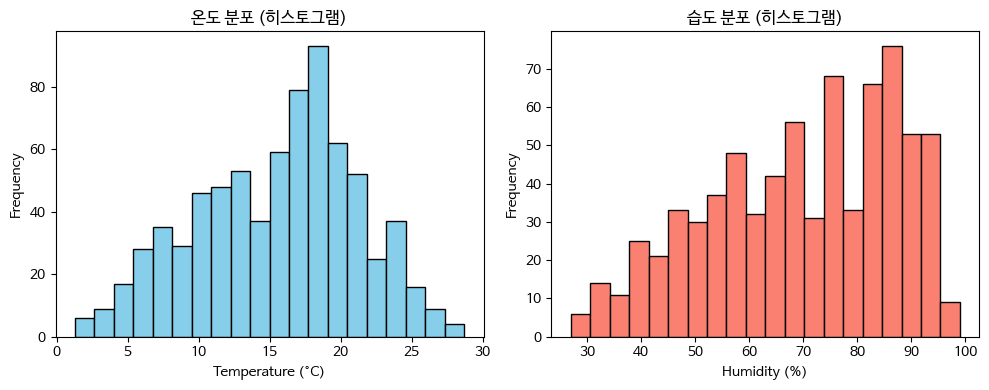

In [ ]:
# 11-2. 기상 데이터 간 관계 : 온도, 습도 히스토그램 (분포 확인)

plt.figure(figsize=(10, 4)) 

plt.subplot(1, 2, 1) # 가로로 두 개의 그래프 배치 중 첫 번째
plt.hist(data['temperature'], bins=20, color='skyblue', edgecolor='black') # 데이터 범위를 20개의 구간으로 나누어 히스토그램 그리기
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('온도 분포 (히스토그램)')

plt.subplot(1, 2, 2) # 가로로 두 개의 그래프 배치 중 두 번째
plt.hist(data['humidity'], bins=20, color='salmon', edgecolor='black')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.title('습도 분포 (히스토그램)')

plt.tight_layout() # 자동 레이아웃 조정
plt.show()

기온은 15도에서 20도 사이에 가장 많은 데이터가 몰려 있고, 습도는 60~90%인 날이 많은 것을 보아, 이 시기는 대체로 습했다.

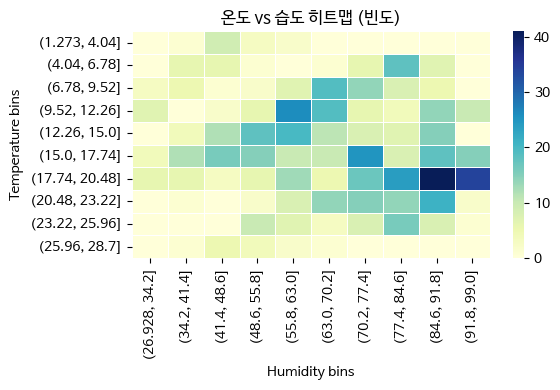

In [10]:
# 11-3. 기상 데이터 간 관계 : 온도 ↔ 습도 히트맵 (빈도 기반)

temp_bins = pd.cut(data['temperature'], bins=10) # 온도 데이터를 10개의 구간으로 나누기
humi_bins = pd.cut(data['humidity'], bins=10) # 습도 데이터를 10개의 구간으로 나누기

pivot_th = pd.crosstab(temp_bins, humi_bins) # 온도 구간별-습도 구간별 빈도 계산

plt.figure(figsize=(6, 4)) # 히트맵 크기 설정
sns.heatmap(
    pivot_th,
    cmap='YlGnBu',     
    linewidths=0.5,
    linecolor='white'
)
plt.xlabel('Humidity bins')
plt.ylabel('Temperature bins')
plt.title('온도 vs 습도 히트맵 (빈도)')
plt.tight_layout()
plt.show()

온도 17~20도와 습도 80~90이 만나는 지점이 가장 많은 것을 보아 덥지 않으면서 습도는 높은 날씨가 가장 많았고, 
온도가 아주 낮고 습도가 아주 낮은 날씨가 거의 없었다.

In [48]:
# 12-1. 기상 데이터 간 관계 : 온도 ↔ 풍속 (이론 + 수치)

# 온도와 풍속의 관계 (이론적 배경)
# - 바람은 주로 기압 차이와 대기 순환에 의해 발생하며, 기온이 높다고 해서 항상 풍속이 커지는 것은 아님.
# - 따라서 온도와 풍속은 뚜렷한 선형 상관관계가 없거나, 있어도 매우 약한 수준일 것으로 예상할 수 있음.

print("=" * 70)
print("기상 데이터 간 관계 : 온도 ↔ 풍속")
print("=" * 70)

corr_temp_wind = data['temperature'].corr(data['wind_speed'])
print("\n[온도 ↔ 풍속 상관계수]")
print(f"상관계수: {corr_temp_wind:.4f}")

print("\n[기본 통계]")
print(f"온도 평균: {data['temperature'].mean():.2f}°C")
print(f"온도 표준편차: {data['temperature'].std():.2f}°C")
print(f"풍속 평균: {data['wind_speed'].mean():.2f} m/s")
print(f"풍속 표준편차: {data['wind_speed'].std():.2f} m/s")


기상 데이터 간 관계 : 온도 ↔ 풍속

[온도 ↔ 풍속 상관계수]
상관계수: 0.2397

[기본 통계]
온도 평균: 15.57°C
온도 표준편차: 5.65°C
풍속 평균: 2.10 m/s
풍속 표준편차: 1.04 m/s


수치 해석 
- 온도와 풍속의 상관계수는 약 0.24로, 약한 양의 상관관계를 보인다.
- 온도가 높을수록 풍속이 다소 증가하는 경향이 있으나, 그 강도는 크지 않다.

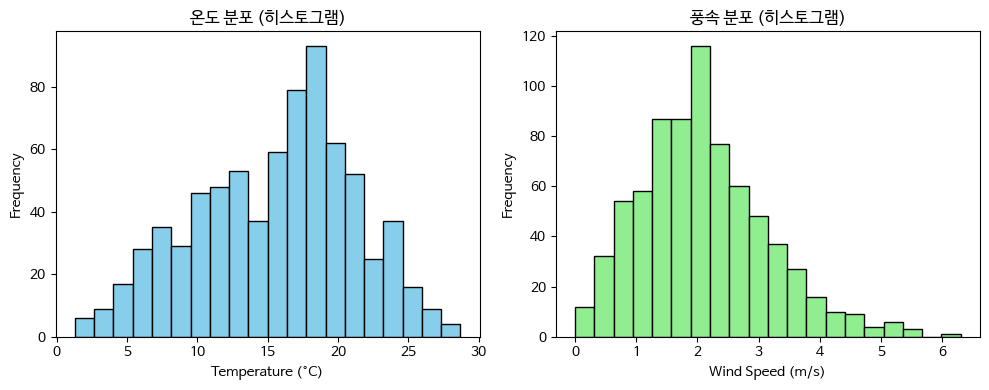

In [49]:
# 12-2. 기상 데이터 간 관계 : 온도, 풍속 히스토그램 (분포 확인)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(data['temperature'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('온도 분포 (히스토그램)')

plt.subplot(1, 2, 2)
plt.hist(data['wind_speed'], bins=20, color='lightgreen', edgecolor='black')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.title('풍속 분포 (히스토그램)')

plt.tight_layout()
plt.show()


히스토그램 해석
: 온도 분포는 약 15~20도 구간에 가장 많이 모여 있으며, 전반적으로 5~25도 사이에 분포한다. 이는 분석 기간 동안 대체로 온화한 기온이 유지되었음을 의미한다.
풍속은 약 2 m/s 근처에 관측이 집중되어 있고, 대부분 0~4 m/s 범위에 분포한다. 즉, 강한 바람보다는 약한 바람이나 미풍이 우세한 시기였다고 볼 수 있다.

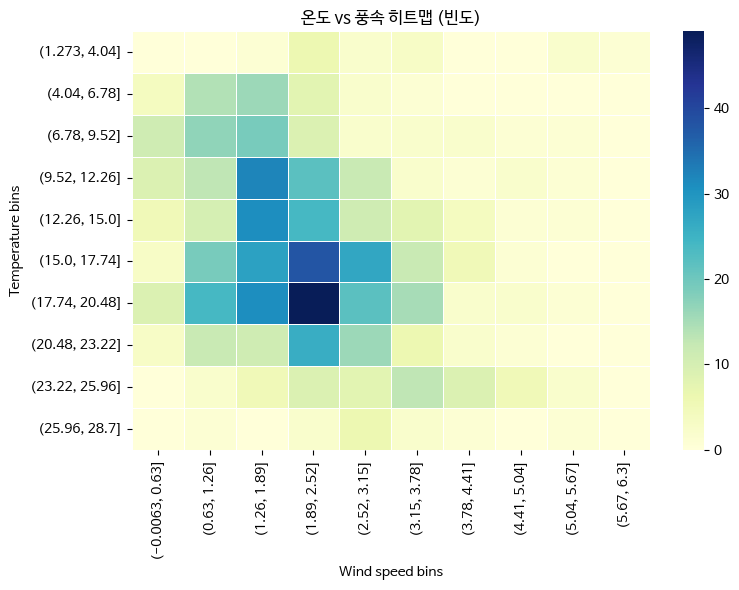

In [ ]:
# 12-3. 기상 데이터 간 관계 : 온도 ↔ 풍속 히트맵 (구간별 빈도)

temp_bins = pd.cut(data['temperature'], bins=10)
wind_bins = pd.cut(data['wind_speed'], bins=10)

pivot_tw = pd.crosstab(temp_bins, wind_bins) #

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_tw,
    cmap='YlGnBu',      
    linewidths=0.5,
    linecolor='white'
)
plt.xlabel('Wind speed bins')
plt.ylabel('Temperature bins')
plt.title('온도 vs 풍속 히트맵 (빈도)')
plt.tight_layout()
plt.show()


히트맵 해석
: 온도–풍속 히트맵에서 가장 진한 구간은 약 15~20°C의 온도와 1~3 m/s 정도의 풍속 구간에 집중되어 있다.
이는 분석 기간 동안 온도가 보통이면서 약한 바람이 부는 날이 가장 자주 관측되었음을 의미하며, 온도와 풍속이 함께 약간 증가하는 경향이 있지만, 특정 구간에만 부분적으로 나타나는 정도라고 볼 수 있다. 

In [ ]:
# 13-1. 기상 데이터 간 관계 : 온도 ↔ 강수량 (이론 + 수치)

# 온도와 강수량의 관계 (이론적 배경)
# - 강수는 기압, 습도, 대기 불안정 등 여러 요인에 의해 발생하며, 단순히 기온만으로 결정되지 않는다.
# - 따라서 온도와 강수량 사이에는 뚜렷한 선형 상관관계가 없거나, 특정 계절·상황에서만 약하게 나타날 가능성이 크다.

print("=" * 70)
print("기상 데이터 간 관계 : 온도 ↔ 강수량")
print("=" * 70)

corr_temp_rain = data['temperature'].corr(data['precipitation']) # 온도와 강수량 간의 상관계수 계산
print("\n[온도 ↔ 강수량 상관계수]")
print(f"상관계수: {corr_temp_rain:.4f}")

print("\n[기본 통계]")
print(f"온도 평균: {data['temperature'].mean():.2f}°C")
print(f"온도 표준편차: {data['temperature'].std():.2f}°C")
print(f"강수량 평균: {data['precipitation'].mean():.2f} mm")
print(f"강수량 표준편차: {data['precipitation'].std():.2f} mm")


기상 데이터 간 관계 : 온도 ↔ 강수량

[온도 ↔ 강수량 상관계수]
상관계수: 0.0439

[기본 통계]
온도 평균: 15.57°C
온도 표준편차: 5.65°C
강수량 평균: 0.08 mm
강수량 표준편차: 0.57 mm


수치 해석 : 상관계수가 0에 매우 가까운 양수(0.04)로, 온도와 강수량 사이에는 뚜렷한 선형 상관관계가 거의 없다고 볼 수 있다.
또한 강수량 평균이 0에 가깝고 표준편차도 매우 작아, 대부분의 날에 강수량이 0mm 또는 매우 적은 수준이었음을 의미한다.

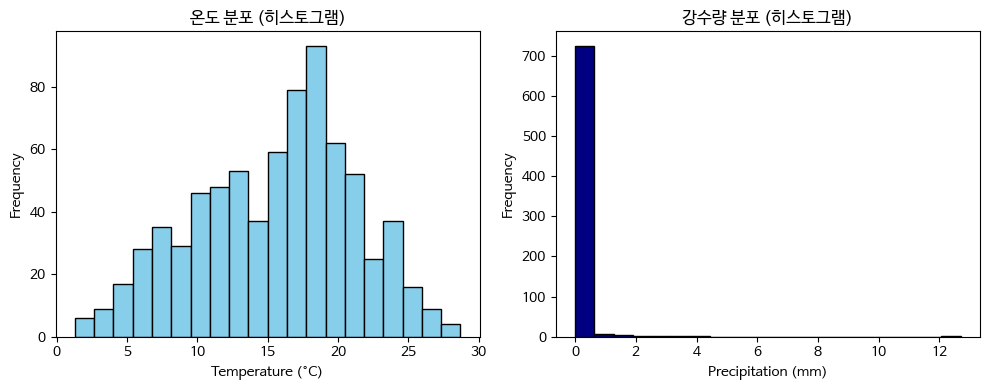

In [52]:
# 13-2. 기상 데이터 간 관계 : 온도, 강수량 히스토그램 (분포 확인)

plt.figure(figsize=(10, 4))

# 온도 분포
plt.subplot(1, 2, 1)
plt.hist(data['temperature'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('온도 분포 (히스토그램)')

# 강수량 분포
plt.subplot(1, 2, 2)
plt.hist(data['precipitation'], bins=20, color='navy', edgecolor='black')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency')
plt.title('강수량 분포 (히스토그램)')

plt.tight_layout()
plt.show()


히스토그램 해석
: 온도는 약 15~20°C 구간에 가장 많이 분포하며, 전체적으로 5~25°C 사이에 집중되어 있다.
강수량은 대부분이 0mm 구간에 몰려 있어 비가 내리지 않은 날이 매우 많고, 강수량이 기록된 날은 극히 적음을 알 수 있다.

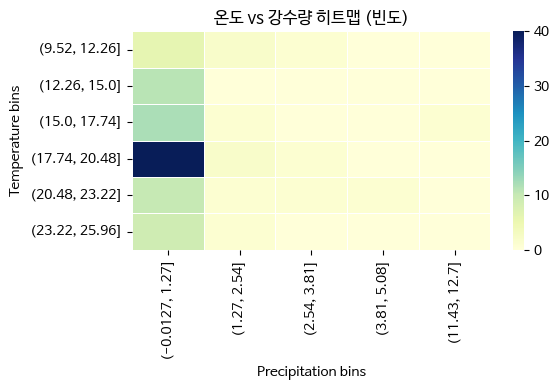

In [11]:
# 13-3. 기상 데이터 간 관계 : 온도 ↔ 강수량 히트맵 (구간별 빈도)

temp_bins = pd.cut(data['temperature'], bins=10)
rain_bins = pd.cut(data['precipitation'], bins=10)

pivot_tr = pd.crosstab(temp_bins, rain_bins)

plt.figure(figsize=(6, 4))
sns.heatmap(
    pivot_tr,
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white'
)
plt.xlabel('Precipitation bins')
plt.ylabel('Temperature bins')
plt.title('온도 vs 강수량 히트맵 (빈도)')
plt.tight_layout()
plt.show()


히트맵 해석
: 온도–강수량 히트맵에서 강수량이 거의 0mm인 구간이 많아, 온도 구간만 여러 칸에 나누어 분포하는 형태를 보인다.
이는 분석 기간 동안 비가 내리지 않은 날이 대부분이었고, 강수량이 기록된 날은 매우 적어, 온도와 강수량 사이의 뚜렷한 패턴이나 상관관계를 확인하기 어렵다는 것을 의미한다.

[기상 데이터 상관계수 행렬]
               temperature  humidity  wind_speed  precipitation
temperature       1.000000  0.175256    0.239709       0.043851
humidity          0.175256  1.000000   -0.204367       0.168212
wind_speed        0.239709 -0.204367    1.000000       0.055063
precipitation     0.043851  0.168212    0.055063       1.000000


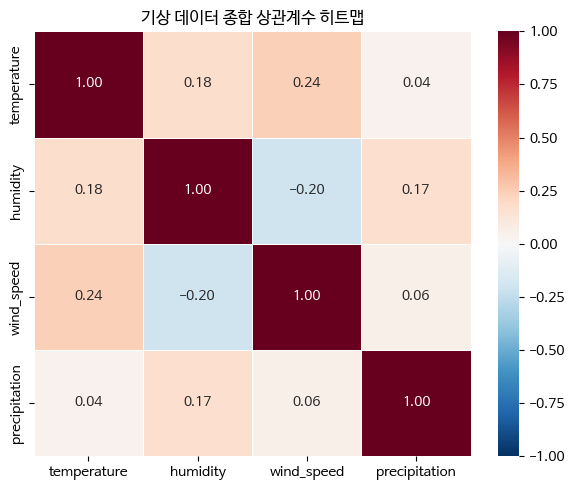

In [ ]:
# 14. 기상 데이터 종합 상관계수 히트맵

# 기상 관련 변수만 선택 
weather_cols = ['temperature', 'humidity', 'wind_speed', 'precipitation']

weather_corr = data[weather_cols].corr()

print("[기상 데이터 상관계수 행렬]")
print(weather_corr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    weather_corr,
    annot=True,         
    fmt=".2f",
    cmap='RdBu_r',      
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white'
)
plt.title('기상 데이터 종합 상관계수 히트맵')
plt.tight_layout()
plt.show()


종합 히트맵 해석
: 기상 변수들 간 상관계수는 모두 절댓값 0.3 미만으로, 전반적으로 약한 상관만 존재한다.
그중 온도–풍속(0.24), 온도–습도(0.18)는 약한 양의 상관을 보이고, 습도–풍속(0.20)은 약한 음의 상관을 보여, 바람이 강할수록 습도가 약간 감소하는 경향이 있다.
나머지 조합과 강수량 관련 상관계수는 거의 0에 가까워 뚜렷한 관계가 없다.

[대기오염 물질 상관계수 행렬]
           PM10     PM2.5       NO2        CO       SO2        O3
PM10   1.000000  0.909359  0.382601  0.555184  0.485263  0.163009
PM2.5  0.909359  1.000000  0.503945  0.651123  0.473446  0.081013
NO2    0.382601  0.503945  1.000000  0.807035  0.265646 -0.552272
CO     0.555184  0.651123  0.807035  1.000000  0.397387 -0.341929
SO2    0.485263  0.473446  0.265646  0.397387  1.000000  0.208397
O3     0.163009  0.081013 -0.552272 -0.341929  0.208397  1.000000


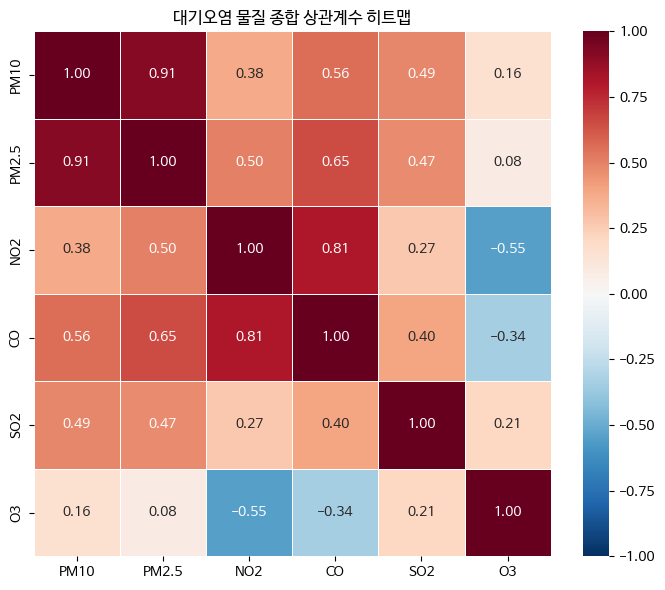

In [55]:
# 15. 대기오염 물질 종합 상관계수 히트맵

# 대기오염 관련 변수만 선택 
pollution_cols = ['PM10', 'PM2.5', 'NO2', 'CO', 'SO2', 'O3']

pollution_corr = data[pollution_cols].corr()

print("[대기오염 물질 상관계수 행렬]")
print(pollution_corr)

plt.figure(figsize=(7, 6))
sns.heatmap(
    pollution_corr,
    annot=True,        
    fmt=".2f",
    cmap='RdBu_r',     
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white'
)
plt.title('대기오염 물질 종합 상관계수 히트맵')
plt.tight_layout()
plt.show()


히트맵 해석
: 대기오염 물질 간 상관계수는 전반적으로 양의 상관이 강하게 나타났다. 특히 PM10–PM2.5(0.91), NO2–CO(0.81), PM2.5–CO(0.65)는 높은 양의 상관을 보여, 유사하거나 함께 증가하는 경향이 강함이 보인다. 반면 NO2–O3(-0.55), CO–O3(-0.34)는 음의 상관을 보여, 질소산화물·일산화탄소 농도가 높을 때 오존 농도는 감소하는 경향을 보인다.

[기상 ↔ 대기오염 상관계수 행렬]
                   PM10     PM2.5       NO2        CO       SO2        O3
temperature   -0.051697 -0.053425 -0.316424 -0.193469  0.052611  0.428432
humidity      -0.167920 -0.021502  0.082987  0.067949 -0.190172 -0.406541
wind_speed    -0.028450 -0.162878 -0.482221 -0.456344 -0.064437  0.395230
precipitation -0.037783 -0.010620 -0.063390 -0.057707 -0.049690  0.035020


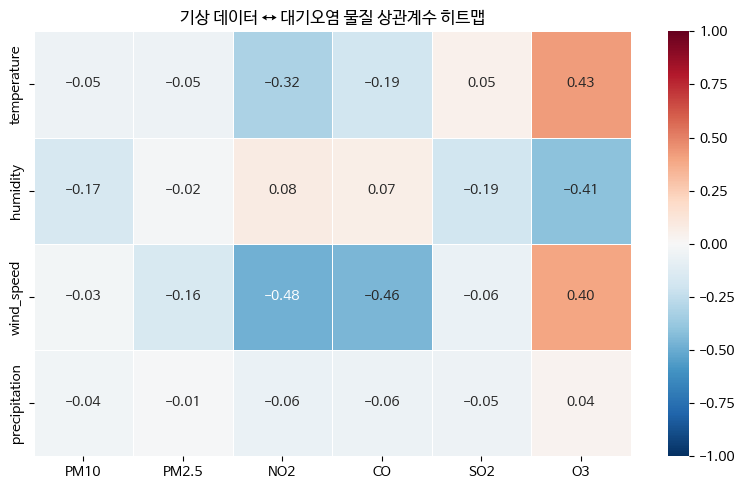

In [56]:
# 16. 기상 데이터 ↔ 대기오염 종합 상관계수 히트맵

# 기상 변수 + 오염 변수 모두 선택
weather_cols = ['temperature', 'humidity', 'wind_speed', 'precipitation']
pollution_cols = ['PM10', 'PM2.5', 'NO2', 'CO', 'SO2', 'O3']

# 두 그룹만 뽑아서 상관계수 계산 (기상 vs 오염 관계만 보기)

all_cols = weather_cols + pollution_cols
corr_matrix = data[all_cols].corr()

# 기상-오염 관계만 보기 (부분 히트맵)
cross_corr = corr_matrix.loc[weather_cols, pollution_cols]

print("[기상 ↔ 대기오염 상관계수 행렬]")
print(cross_corr)

plt.figure(figsize=(8, 5))
sns.heatmap(
    cross_corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white'
)
plt.title('기상 데이터 ↔ 대기오염 물질 상관계수 히트맵')
plt.tight_layout()
plt.show()


히트맵 해석
: 기상요소와 대기오염 물질 간 상관계수는 대부분 절댓값 0.3 이하로 약한 수준이었으나, 몇 가지 눈에 띄는 경향이 관찰되었다. 온도와 O₃(0.43), 풍속과 O₃(0.40)는 비교적 뚜렷한 양의 상관을 보여, 기온이 높고 바람이 강할수록 오존 농도가 함께 증가하는 경향이 있었다. 반대로 풍속은 NO₂(-0.48), CO(-0.46)와 중간 정도의 음의 상관을 보여, 바람이 강할수록 질소산화물과 일산화탄소 농도는 낮아지는 경향을 보였다.

In [ ]:
# 17-1. 일별 PM10 평균 수치 계산

# datetime을 날짜로 변환 (시간 제거)
data['date'] = pd.to_datetime(data['datetime']).dt.date

# 일별 PM10 평균 계산
daily_pm10 = data.groupby('date')['PM10'].mean().reset_index()

print("[일별 PM10 평균 농도]")
print(daily_pm10.head())

[일별 PM10 평균 농도]
         date       PM10
0  2021-10-01  34.304348
1  2021-10-02  23.916667
2  2021-10-03  35.666667
3  2021-10-04  36.875000
4  2021-10-05  39.041667


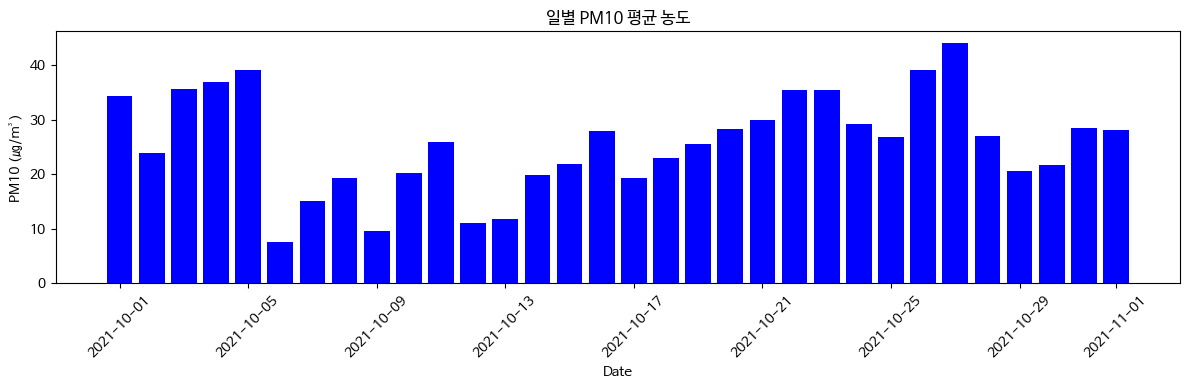

In [63]:
# 17-2. 일별 PM10 평균 막대그래프

plt.figure(figsize=(12, 4))
plt.bar(daily_pm10['date'], daily_pm10['PM10'], color='blue')
plt.xlabel('Date')
plt.ylabel('PM10 (㎍/m³)')
plt.title('일별 PM10 평균 농도')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


막대 그래프 해석
: 일별 PM10 평균 농도는 대체로 10~40 ㎍/m³ 범위에서 변동하며, 중순 이후로 점차 증가하는 경향을 보인다. 특히 10월 말(예: 10월 26~28일경)에 40 ㎍/m³ 이상으로 뚜렷하게 높아진 날이 나타나, 이 기간에 단기적인 대기질 악화가 있었음을 볼 수 있다.

In [ ]:
# 18-1. 일별 PM2.5 평균 수치 계산

data['date'] = pd.to_datetime(data['datetime']).dt.date  

daily_pm25 = data.groupby('date')['PM2.5'].mean().reset_index()

print("[일별 PM2.5 평균 농도]")
print(daily_pm25.head())


[일별 PM2.5 평균 농도]
         date      PM2.5
0  2021-10-01  19.086957
1  2021-10-02  12.625000
2  2021-10-03  21.833333
3  2021-10-04  18.791667
4  2021-10-05  15.375000


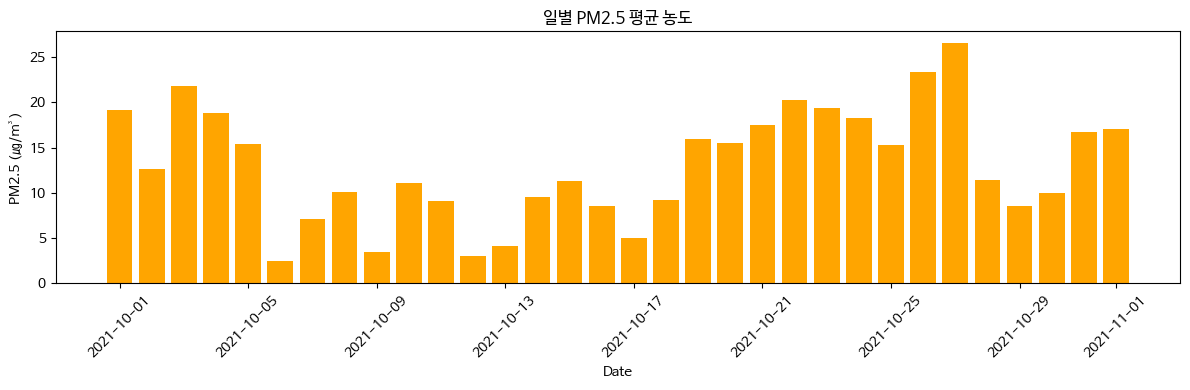

In [62]:
# 18-2. 일별 PM2.5 평균 막대그래프

plt.figure(figsize=(12, 4))
plt.bar(daily_pm25['date'], daily_pm25['PM2.5'], color='orange')
plt.xlabel('Date')
plt.ylabel('PM2.5 (㎍/m³)')
plt.title('일별 PM2.5 평균 농도')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


막대 그래프 해석
: 일별 PM2.5 평균 농도는 초반에는 10~20 ㎍/m³ 수준에서 비교적 낮게 유지되다가, 10월 중·후반부터 점차 상승하는 경향을 보였다. 특히 10월 25일 이후에는 20 ㎍/m³를 넘는 날이 여러 번 나타났고, 10월 말에는 25~27 ㎍/m³ 수준까지 높아져 PM10과 비슷한 시기에 고농도 구간이 형성되었다.

전체 분석 결과 요약

## (1) 기상 변수 간 관계
- 온도–습도: 약한 양의 상관 (r ≈ 0.1~0.3), 산점도에서 퍼져 있으나 대체로 온도↑ 시 습도도 소폭↑
- 온도–풍속: 약한 양의 상관 (r ≈ 0.2 전후)
- 습도–풍속: 약한 음의 상관 (r ≈ -0.2 전후)
- 강수량: 대부분 0mm 구간에 몰려 있고, 다른 변수들과 상관계수 거의 0

## (2) 대기오염 물질 간 관계
- PM10–PM2.5: 강한 양의 상관 (r ≈ 0.91)
- NO₂–CO: 강한 양의 상관 (r ≈ 0.81)
- PM2.5–CO: 비교적 강한 양의 상관 (r ≈ 0.65)
- PM10/PM2.5–NO₂/CO/SO₂: 전반적으로 양의 상관
- NO₂–O₃: 뚜렷한 음의 상관 (r ≈ -0.55)
- CO–O₃: 약~중간 음의 상관 (r ≈ -0.34)

## (3) 기상 ↔ 대기오염 관계
- 온도–O₃: 중간 정도 양의 상관 (r ≈ 0.43)
- 풍속–O₃: 중간 정도 양의 상관 (r ≈ 0.40)
- 풍속–NO₂: 중간 정도 음의 상관 (r ≈ -0.48)
- 풍속–CO: 중간 정도 음의 상관 (r ≈ -0.46)
- 그 외 기상–오염 조합: 대부분 약한 상관 (|r| < 0.3)

## (4) 일별 PM10 / PM2.5
- PM10 일별 평균: 대체로 10~40 ㎍/m³ 사이에서 변동, 10월 말에 40 이상 피크 구간 존재
- PM2.5 일별 평균: 초반 10~20 ㎍/m³, 중·후반부터 증가, PM10 피크 시기와 유사한 고농도 구간 형성

## 전체 요약
본 분석에서는 기상 변수와 대기오염 물질 간의 관계를 단계적으로 확인하며, 단순한 수치 나열이 아니라 각 결과가 무엇을 의미하는지 해석하는 데 초점을 두었다.

먼저 기온, 습도, 풍속, 강수량 간 상관분석과 산점도·히트맵을 통해, 기상 변수들 사이에는 전반적으로 약한 상관만 존재하며, 특히 강수량은 다른 변수들과 거의 독립적으로 변동한다는 점을 확인하였다. 이후 기상 변수만을 모은 종합 상관계수 히트맵을 작성하여, 온도–풍속, 온도–습도, 습도–풍속 사이에 약한 수준의 양·음의 상관이 존재함을 해석하였다.

다음으로 PM10, PM2.5, NO₂, CO, SO₂, O₃ 등 대기오염 물질 간 상관계수를 계산하고 히트맵을 통해 시각화하였다. 그 결과 PM10–PM2.5, NO₂–CO처럼 배출원이 유사한 물질들 사이에서 강한 양의 상관이 나타났고, NO₂–O₃, CO–O₃에서 뚜렷한 음의 상관이 관찰되어, 광화학 반응과 희석 효과 등 대기화학·기상 조건의 영향을 함께 고려해야 함을 확인하였다. 이는 단순히 상관계수 값만 보는 것이 아니라, 오염물질의 특성과 생성·소멸 메커니즘을 함께 연결해 해석했다는 점에서 의미가 있다.

또한 기상 변수와 대기오염 물질을 한 번에 포함한 종합 상관계수 히트맵을 통해, 온도·풍속·습도와 각 오염물질의 관계를 비교하였다. 특히 풍속이 NO₂와 CO와는 음의 상관, O₃와는 양의 상관을 보인다는 결과를 통해, 바람이 질소산화물·일산화탄소는 희석시키는 반면, 오존 형성에는 오히려 유리한 조건을 만들 수 있음을 추론하였다. 이를 통해 상관분석이 단순 통계량 계산이 아니라, 기상과 대기질 사이의 물리·화학적 관계를 이해하는 도구로 활용될 수 있음을 확인하였다.

마지막으로 datetime 정보를 날짜 단위로 변환하여 일별 PM10, PM2.5 평균을 계산하고 막대그래프로 시각화하였다. 이를 통해 기간 전체에서 농도가 비교적 안정적으로 유지되는 구간과, 특정 일자에 고농도 피크가 나타나는 구간을 구분할 수 있었으며, 두 물질의 피크 시점이 유사하게 나타나는지 비교함으로써 앞서 확인한 PM10–PM2.5 간 높은 상관관계를 시간 축에서 다시 한 번 검증하였다. 이처럼 본 분석은 전처리(날짜 변환, 그룹화) → 수치 계산(상관계수, 일별 평균) → 시각화(산점도, 히트맵, 막대그래프) → 해석(물리·화학적 의미 연결)이라는 일련의 과정을 통해, 데이터 구조와 변수 간 관계를 스스로 이해하고 설명할 수 있음을 보여준다. 